In [1]:
# ENVIRONMENT SETUP & PACKAGE INSTALLATION
# Run this cell first to install all required packages

# Install required packages (run once)
# !pip install mne>=1.6.0
# !pip install torch>=2.0.0
# !pip install ruptures>=1.1.9
# !pip install numpy pandas matplotlib seaborn scipy scikit-learn
# !pip install h5py tqdm pyEDFlib

In [2]:
# IMPORT LIBRARIES

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# EEG-specific libraries
import mne
from mne.datasets import sleep_physionet

# Signal processing
from scipy import signal
from scipy.stats import zscore

# Changepoint detection
import ruptures as rpt

# Deep learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# For saving processed data
import h5py
import pickle

print(f"MNE version: {mne.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"Ruptures version: {rpt.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

MNE version: 1.11.0
PyTorch version: 2.1.2+cu121
Ruptures version: v1.1.10
GPU available: False


In [3]:
# PROJECT CONFIGURATION
# Define all hyperparameters and paths in one place for easy modification

class Config:
    """
    Central configuration class for the entire project.
    Modify these parameters to adjust preprocessing and model settings.
    """
    # Paths
    DATA_DIR = Path("./data")
    RAW_DIR = DATA_DIR / "raw"
    PROCESSED_DIR = DATA_DIR / "processed"
    FIGURES_DIR = Path("./figures")
    
    # Dataset Settings 
    DATASET_NAME = "sleep-edf"
    N_SUBJECTS = 78  # all available subjects
    
    # EEG Preprocessing Parameters
    SFREQ_ORIGINAL = 100  # Sleep-EDF sampling frequency
    SFREQ_TARGET = 100    # Target sampling frequency (no resampling needed)
    
    # Filtering parameters
    L_FREQ = 0.5          # High-pass filter cutoff (Hz)
    H_FREQ = 35.0         # Low-pass filter cutoff (Hz) - removes muscle artifacts
    NOTCH_FREQ = None     # No notch filter needed (European data at 50Hz already filtered)
    
    # Epoching parameters
    EPOCH_DURATION = 30.0  # seconds (standard for sleep staging)
    EPOCH_OVERLAP = 0.0    # No overlap for standard sleep staging
    
    # Normalization
    NORMALIZATION = "zscore"  # Options: "zscore", "robust", "minmax"
    
    # Channel Selection
    # Sleep-EDF uses Fpz-Cz and Pz-Oz channels
    EEG_CHANNELS = ['EEG Fpz-Cz', 'EEG Pz-Oz']
    EOG_CHANNEL = 'EOG horizontal'
    
    # Sleep Stage Mapping 
    # AASM standard: W=0, N1=1, N2=2, N3=3, REM=4
    STAGE_MAPPING = {
        'Sleep stage W': 0,
        'Sleep stage 1': 1,
        'Sleep stage 2': 2,
        'Sleep stage 3': 3,
        'Sleep stage 4': 3,  # Combine N3 and N4 (old R&K standard)
        'Sleep stage R': 4,
        'Sleep stage ?': -1,  # Unknown/Movement - will be excluded
        'Movement time': -1
    }
    
    STAGE_NAMES = ['Wake', 'N1', 'N2', 'N3', 'REM']
    
    # Changepoint Detection
    CP_MODEL = "rbf"      # Cost function for PELT
    CP_MIN_SIZE = 100     # Minimum segment size (1 second at 100Hz)
    CP_PENALTY = 10       # Penalty for adding changepoints (tune this)
    
    # Random Seed
    SEED = 42

# Create directories
for dir_path in [Config.DATA_DIR, Config.RAW_DIR, Config.PROCESSED_DIR, Config.FIGURES_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

print("Configuration loaded successfully!")
print(f"Data directory: {Config.DATA_DIR.absolute()}")

Configuration loaded successfully!
Data directory: /datasets/_deepnote_work/data


In [4]:
# # DOWNLOAD SLEEP-EDF DATASET (BOTH NIGHTS)
# # Downloads the Sleep-EDF dataset from PhysioNet via MNE

# def download_sleep_edf(n_subjects=Config.N_SUBJECTS):
#     """
#     Download Sleep-EDF dataset using MNE's built-in fetcher.
#     Downloads BOTH nights per subject for maximum data.
    
#     The Sleep-EDF database (Sleep Cassette portion):
#     - 78 subjects (indices 0-77)
#     - Up to 2 nights per subject
#     - ~153 total recordings
#     - ~500+ hours of data
    
#     Parameters:
#     -----------
#     n_subjects : int
#         Number of subjects to download (max 78)
    
#     Returns:
#     --------
#     list : Paths to downloaded PSG files
#     list : Paths to corresponding hypnogram (annotation) files
#     """
#     print(f"Downloading Sleep-EDF dataset for {n_subjects} subjects (both nights)...")
#     print("This may take several minutes on first run...\n")
    
#     psg_files = []
#     hypno_files = []
    
#     for subject_id in tqdm(range(n_subjects), desc="Downloading subjects"):
#         for night in [1, 2]:  # Download BOTH nights
#             try:
#                 paths = sleep_physionet.age.fetch_data(
#                     subjects=[subject_id],
#                     recording=[night],
#                     path=str(Config.RAW_DIR),
#                     on_missing='ignore'  # Skip silently if night 2 doesn't exist
#                 )
                
#                 if len(paths) > 0:
#                     psg_files.append(paths[0][0])
#                     hypno_files.append(paths[0][1])
                    
#             except Exception as e:
#                 # Some subjects only have 1 night - this is expected
#                 continue
    
#     print(f"\n✓ Successfully downloaded {len(psg_files)} recordings from {n_subjects} subjects")
#     print(f"  Estimated total hours: ~{len(psg_files) * 7} hours")
    
#     return psg_files, hypno_files

# # Execute download
# psg_files, hypno_files = download_sleep_edf()

# print(f"\nTotal recordings: {len(psg_files)}")
# print(f"\nSample paths:")
# print(f"  PSG: {psg_files[0]}")
# print(f"  Hypnogram: {hypno_files[0]}")

 91%|██████████████████████████████████▌   | 45.7M/50.3M [02:04<00:11, 386kB/s]
 91%|██████████████████████████████████▌   | 45.7M/50.3M [02:04<00:11, 385kB/s]
 91%|██████████████████████████████████▌   | 45.8M/50.3M [02:04<00:11, 384kB/s]
 91%|██████████████████████████████████▋   | 45.8M/50.3M [02:04<00:11, 383kB/s]
 91%|██████████████████████████████████▋   | 45.9M/50.3M [02:05<00:11, 385kB/s]
 91%|██████████████████████████████████▋   | 45.9M/50.3M [02:05<00:11, 382kB/s]
 91%|██████████████████████████████████▊   | 46.0M/50.3M [02:05<00:11, 375kB/s]
 92%|██████████████████████████████████▊   | 46.0M/50.3M [02:05<00:11, 373kB/s]
 92%|██████████████████████████████████▊   | 46.1M/50.3M [02:05<00:11, 372kB/s]
 92%|██████████████████████████████████▊   | 46.1M/50.3M [02:05<00:11, 372kB/s]
 92%|██████████████████████████████████▉   | 46.2M/50.3M [02:05<00:11, 368kB/s]
 92%|██████████████████████████████████▉   | 46.2M/50.3M [02:05<00:11, 362kB/s]
 92%|██████████████████████████████████▉

In [5]:
# Check how many subjects are available via MNE
from mne.datasets import sleep_physionet

print("Checking available subjects in Sleep-EDF via MNE...")
print(f"Subject indices available: 0 to 77")
print(f"Recordings per subject: 1 or 2 nights")

# Count what we currently have downloaded
existing_psg = list(Config.RAW_DIR.glob("**/SC*-PSG.edf"))
print(f"\nCurrently downloaded: {len(existing_psg)} recordings")

Checking available subjects in Sleep-EDF via MNE...
Subject indices available: 0 to 77
Recordings per subject: 1 or 2 nights

Currently downloaded: 147 recordings


In [6]:
# LOAD AND INSPECT RAW EEG DATA
# Learn about the data structure before preprocessing

def load_raw_eeg(psg_file, hypno_file, verbose=False):
    """
    Load a single PSG recording and its annotations.
    
    Parameters:
    -----------
    psg_file : str
        Path to the PSG EDF file
    hypno_file : str
        Path to the hypnogram annotation file
    verbose : bool
        Whether to print detailed info
        
    Returns:
    --------
    mne.io.Raw : Raw EEG data object
    mne.Annotations : Sleep stage annotations
    """
    # Load the raw EEG data
    raw = mne.io.read_raw_edf(psg_file, preload=True, verbose=verbose)
    
    # Load sleep stage annotations
    annotations = mne.read_annotations(hypno_file)
    
    # Attach annotations to raw data
    raw.set_annotations(annotations)
    
    return raw, annotations

def inspect_raw_data(raw, annotations):
    """
    Print detailed information about the raw EEG recording.
    """
    print("=" * 60)
    print("RAW EEG DATA INSPECTION")
    print("=" * 60)
    
    # Basic info
    print(f"\n1. RECORDING INFO:")
    print(f"   Duration: {raw.times[-1] / 3600:.2f} hours")
    print(f"   Sampling frequency: {raw.info['sfreq']} Hz")
    print(f"   Number of channels: {len(raw.ch_names)}")
    
    # Channel info
    print(f"\n2. CHANNELS:")
    for i, ch in enumerate(raw.ch_names):
        ch_type = mne.channel_type(raw.info, i)
        print(f"   [{i}] {ch} ({ch_type})")
    
    # Data shape
    data = raw.get_data()
    print(f"\n3. DATA SHAPE:")
    print(f"   Shape: {data.shape} (channels × samples)")
    print(f"   Total samples: {data.shape[1]:,}")
    
    # Annotation info
    print(f"\n4. SLEEP STAGE ANNOTATIONS:")
    unique_stages = np.unique(annotations.description)
    print(f"   Unique stages: {unique_stages}")
    
    # Count epochs per stage
    stage_counts = pd.Series(annotations.description).value_counts()
    print(f"\n   Stage distribution (30s epochs):")
    for stage, count in stage_counts.items():
        hours = count * 30 / 3600
        print(f"   {stage}: {count} epochs ({hours:.2f} hours)")
    
    # Data statistics
    print(f"\n5. SIGNAL STATISTICS:")
    for i, ch in enumerate(raw.ch_names):
        ch_data = data[i]
        print(f"   {ch}:")
        print(f"      Mean: {ch_data.mean():.2f} μV")
        print(f"      Std:  {ch_data.std():.2f} μV")
        print(f"      Range: [{ch_data.min():.2f}, {ch_data.max():.2f}] μV")

# Load and inspect first recording
print("Loading first recording for inspection...")
raw, annotations = load_raw_eeg(psg_files[0], hypno_files[0])
inspect_raw_data(raw, annotations)

Loading first recording for inspection...
RAW EEG DATA INSPECTION

1. RECORDING INFO:
   Duration: 22.08 hours
   Sampling frequency: 100.0 Hz
   Number of channels: 7

2. CHANNELS:
   [0] EEG Fpz-Cz (eeg)
   [1] EEG Pz-Oz (eeg)
   [2] EOG horizontal (eeg)
   [3] Resp oro-nasal (eeg)
   [4] EMG submental (eeg)
   [5] Temp rectal (eeg)
   [6] Event marker (eeg)

3. DATA SHAPE:
   Shape: (7, 7950000) (channels × samples)
   Total samples: 7,950,000

4. SLEEP STAGE ANNOTATIONS:
   Unique stages: ['Sleep stage 1' 'Sleep stage 2' 'Sleep stage 3' 'Sleep stage 4'
 'Sleep stage ?' 'Sleep stage R' 'Sleep stage W']

   Stage distribution (30s epochs):
   Sleep stage 3: 48 epochs (0.40 hours)
   Sleep stage 2: 40 epochs (0.33 hours)
   Sleep stage 1: 24 epochs (0.20 hours)
   Sleep stage 4: 23 epochs (0.19 hours)
   Sleep stage W: 12 epochs (0.10 hours)
   Sleep stage R: 6 epochs (0.05 hours)
   Sleep stage ?: 1 epochs (0.01 hours)

5. SIGNAL STATISTICS:
   EEG Fpz-Cz:
      Mean: 0.00 μV
      S

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Figure saved to figures/raw_eeg_segment.png


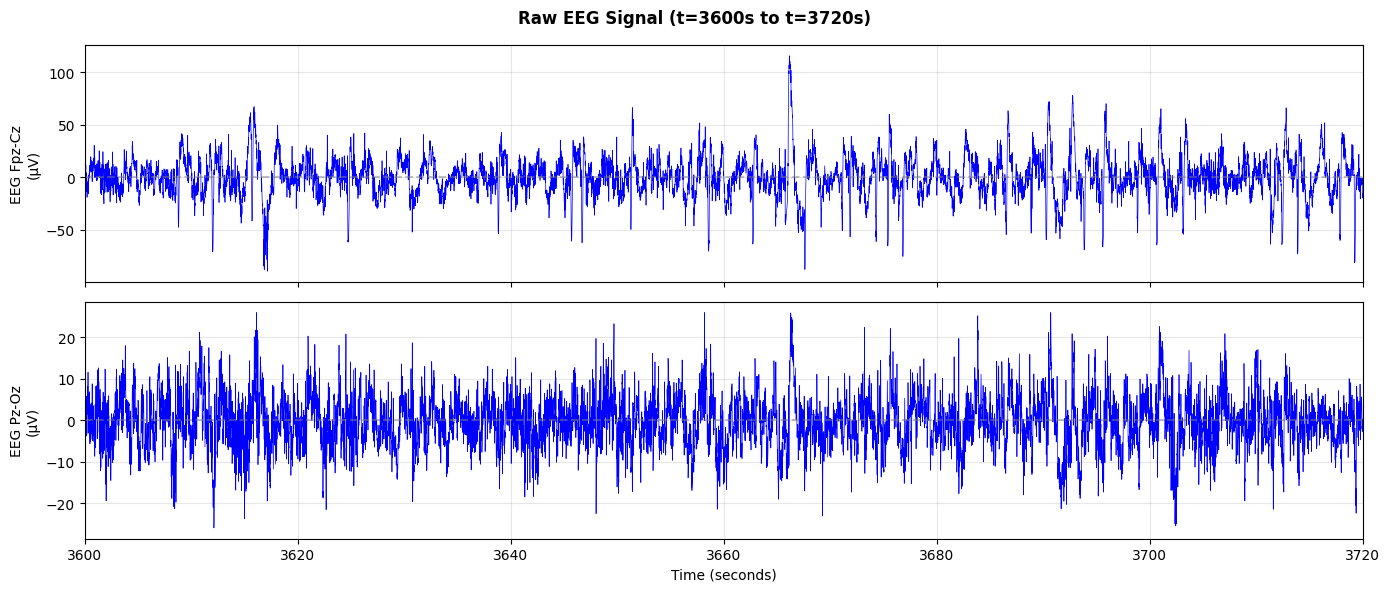

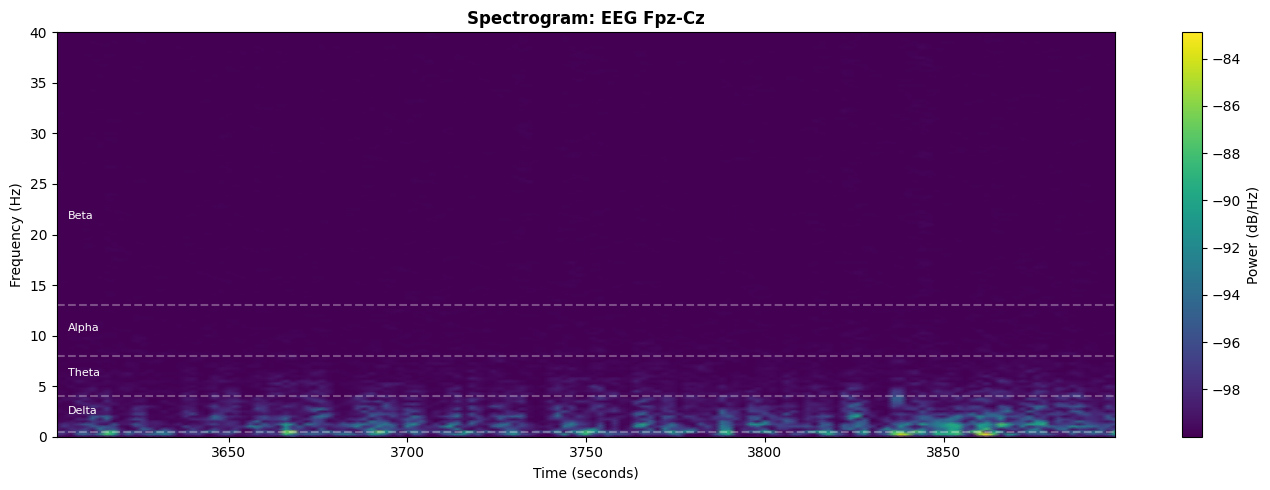

In [7]:
# VISUALIZE RAW EEG DATA
# Plot raw signals and spectrograms to understand the data

def plot_raw_eeg_segment(raw, start_time=0, duration=120, save_path=None):
    """
    Plot a segment of raw EEG data.
    
    Parameters:
    -----------
    raw : mne.io.Raw
        Raw EEG data
    start_time : float
        Start time in seconds
    duration : float
        Duration to plot in seconds
    save_path : str, optional
        Path to save the figure
    """
    # Select EEG channels only
    eeg_channels = [ch for ch in raw.ch_names if 'EEG' in ch]
    raw_eeg = raw.copy().pick_channels(eeg_channels)
    
    # Get data segment
    start_sample = int(start_time * raw.info['sfreq'])
    end_sample = int((start_time + duration) * raw.info['sfreq'])
    data = raw_eeg.get_data()[:, start_sample:end_sample]
    times = np.linspace(start_time, start_time + duration, data.shape[1])
    
    # Create figure
    fig, axes = plt.subplots(len(eeg_channels), 1, figsize=(14, 3*len(eeg_channels)), 
                             sharex=True)
    if len(eeg_channels) == 1:
        axes = [axes]
    
    for i, (ax, ch_name) in enumerate(zip(axes, eeg_channels)):
        ax.plot(times, data[i] * 1e6, 'b-', linewidth=0.5)  # Convert to μV
        ax.set_ylabel(f'{ch_name}\n(μV)')
        ax.set_xlim(start_time, start_time + duration)
        ax.grid(True, alpha=0.3)
        
        # Add amplitude scale
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    
    axes[-1].set_xlabel('Time (seconds)')
    fig.suptitle(f'Raw EEG Signal (t={start_time}s to t={start_time+duration}s)', 
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()

def plot_spectrogram(raw, channel='EEG Fpz-Cz', start_time=0, duration=300, save_path=None):
    """
    Plot spectrogram of EEG channel to visualize frequency content over time.
    
    Parameters:
    -----------
    raw : mne.io.Raw
        Raw EEG data
    channel : str
        Channel name to plot
    start_time : float
        Start time in seconds
    duration : float
        Duration to analyze in seconds
    """
    # Get channel data
    ch_idx = raw.ch_names.index(channel)
    start_sample = int(start_time * raw.info['sfreq'])
    end_sample = int((start_time + duration) * raw.info['sfreq'])
    data = raw.get_data()[ch_idx, start_sample:end_sample]
    
    # Compute spectrogram
    fs = raw.info['sfreq']
    nperseg = int(fs * 4)  # 4-second windows
    noverlap = int(fs * 2)  # 50% overlap
    
    f, t, Sxx = signal.spectrogram(data, fs=fs, nperseg=nperseg, 
                                    noverlap=noverlap, scaling='density')
    
    # Limit frequency range
    freq_mask = f <= 40
    f = f[freq_mask]
    Sxx = Sxx[freq_mask, :]
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 5))
    
    # Use log scale for better visualization
    im = ax.pcolormesh(t + start_time, f, 10 * np.log10(Sxx + 1e-10), 
                       shading='gouraud', cmap='viridis')
    
    ax.set_ylabel('Frequency (Hz)')
    ax.set_xlabel('Time (seconds)')
    ax.set_title(f'Spectrogram: {channel}', fontsize=12, fontweight='bold')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Power (dB/Hz)')
    
    # Mark typical EEG bands
    bands = {'Delta': (0.5, 4), 'Theta': (4, 8), 'Alpha': (8, 13), 'Beta': (13, 30)}
    for band_name, (low, high) in bands.items():
        ax.axhline(y=low, color='white', linestyle='--', alpha=0.3)
        ax.text(start_time + 5, (low + high)/2, band_name, color='white', fontsize=8)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()

# Plot raw signal (2 minutes starting at 1 hour into recording)
plot_raw_eeg_segment(raw, start_time=3600, duration=120, 
                     save_path=Config.FIGURES_DIR / "raw_eeg_segment.png")

# Plot spectrogram (5 minutes)
plot_spectrogram(raw, channel='EEG Fpz-Cz', start_time=3600, duration=300,
                 save_path=Config.FIGURES_DIR / "spectrogram.png")

In [8]:
# EEG PREPROCESSING PIPELINE
# Core preprocessing functions: filtering, artifact handling, epoching

class EEGPreprocessor:
    """
    Comprehensive EEG preprocessing pipeline for sleep staging.
    
    This class handles:
    1. Channel selection
    2. Filtering (bandpass)
    3. Artifact detection/rejection
    4. Epoching (30-second windows for sleep staging)
    5. Normalization
    6. Sleep stage label extraction
    """
    
    def __init__(self, config=Config):
        """Initialize preprocessor with configuration."""
        self.config = config
        self.sfreq = config.SFREQ_TARGET
        
    def select_channels(self, raw):
        """
        Select relevant EEG and EOG channels.
        
        Parameters:
        -----------
        raw : mne.io.Raw
            Raw EEG data
            
        Returns:
        --------
        mne.io.Raw : Raw data with selected channels only
        """
        # Find available channels that match our target channels
        available_channels = []
        for ch in self.config.EEG_CHANNELS + [self.config.EOG_CHANNEL]:
            if ch in raw.ch_names:
                available_channels.append(ch)
            else:
                print(f"  Warning: Channel '{ch}' not found in recording")
        
        if len(available_channels) == 0:
            raise ValueError("No matching channels found!")
        
        # Pick channels
        raw_selected = raw.copy().pick_channels(available_channels)
        
        return raw_selected
    
    def apply_filters(self, raw):
        """
        Apply bandpass filter to remove noise outside frequency range of interest.
        
        EEG frequency bands of interest:
        - Delta (0.5-4 Hz): Deep sleep
        - Theta (4-8 Hz): Light sleep, drowsiness
        - Alpha (8-13 Hz): Relaxed wakefulness
        - Beta (13-30 Hz): Active thinking, REM
        
        We filter 0.5-35 Hz to capture all relevant bands while removing:
        - DC drift (< 0.5 Hz)
        - Muscle artifacts (> 35 Hz)
        - Line noise (50/60 Hz)
        """
        print(f"  Applying bandpass filter: {self.config.L_FREQ}-{self.config.H_FREQ} Hz")
        
        # Apply bandpass filter
        raw_filtered = raw.copy().filter(
            l_freq=self.config.L_FREQ,
            h_freq=self.config.H_FREQ,
            fir_design='firwin',
            skip_by_annotation='edge',
            verbose=False
        )
        
        return raw_filtered
    
    def detect_bad_epochs(self, epochs_data, threshold_uv=500):
        """
        Detect epochs with artifacts based on amplitude threshold.
        
        Parameters:
        -----------
        epochs_data : np.ndarray
            Epoched data of shape (n_epochs, n_channels, n_samples)
        threshold_uv : float
            Amplitude threshold in microvolts
            
        Returns:
        --------
        np.ndarray : Boolean mask where True = bad epoch
        """
        # Convert to microvolts if needed
        data_uv = epochs_data * 1e6 if epochs_data.max() < 1 else epochs_data
        
        # Check peak-to-peak amplitude per epoch
        ptp = np.ptp(data_uv, axis=2)  # Peak-to-peak per channel per epoch
        max_ptp = ptp.max(axis=1)       # Max across channels
        
        bad_mask = max_ptp > threshold_uv
        
        return bad_mask
    
    def extract_epochs_and_labels(self, raw, annotations):
        """
        Extract 30-second epochs and corresponding sleep stage labels.
        
        Parameters:
        -----------
        raw : mne.io.Raw
            Preprocessed raw EEG data
        annotations : mne.Annotations
            Sleep stage annotations
            
        Returns:
        --------
        np.ndarray : Epoched data (n_epochs, n_channels, n_samples)
        np.ndarray : Sleep stage labels (n_epochs,)
        np.ndarray : Epoch start times (n_epochs,)
        """
        sfreq = raw.info['sfreq']
        epoch_samples = int(self.config.EPOCH_DURATION * sfreq)
        
        epochs_list = []
        labels_list = []
        times_list = []
        
        # Get data array
        data = raw.get_data()
        
        # Process each annotation (each is a 30-second epoch)
        for annot in annotations:
            # Get stage label
            stage_name = annot['description']
            if stage_name not in self.config.STAGE_MAPPING:
                continue
            
            label = self.config.STAGE_MAPPING[stage_name]
            if label == -1:  # Skip unknown/movement epochs
                continue
            
            # Get epoch timing
            onset = annot['onset']
            duration = annot['duration']
            
            # Skip if annotation is not 30 seconds
            if abs(duration - 30.0) > 1.0:
                continue
            
            # Extract epoch
            start_sample = int(onset * sfreq)
            end_sample = start_sample + epoch_samples
            
            # Check bounds
            if start_sample < 0 or end_sample > data.shape[1]:
                continue
            
            epoch = data[:, start_sample:end_sample]
            
            # Verify shape
            if epoch.shape[1] != epoch_samples:
                continue
            
            epochs_list.append(epoch)
            labels_list.append(label)
            times_list.append(onset)
        
        # Convert to arrays
        epochs = np.array(epochs_list)
        labels = np.array(labels_list)
        times = np.array(times_list)
        
        return epochs, labels, times
    
    def normalize_epochs(self, epochs, method='zscore'):
        """
        Normalize epochs to have consistent scale.
        
        Parameters:
        -----------
        epochs : np.ndarray
            Epoched data (n_epochs, n_channels, n_samples)
        method : str
            Normalization method: 'zscore', 'robust', or 'minmax'
            
        Returns:
        --------
        np.ndarray : Normalized epochs
        """
        normalized = np.zeros_like(epochs)
        
        for i in range(epochs.shape[0]):
            for j in range(epochs.shape[1]):
                segment = epochs[i, j, :]
                
                if method == 'zscore':
                    # Z-score normalization (mean=0, std=1)
                    mean = np.mean(segment)
                    std = np.std(segment)
                    if std > 0:
                        normalized[i, j, :] = (segment - mean) / std
                    else:
                        normalized[i, j, :] = segment - mean
                        
                elif method == 'robust':
                    # Robust normalization using median and IQR
                    median = np.median(segment)
                    iqr = np.percentile(segment, 75) - np.percentile(segment, 25)
                    if iqr > 0:
                        normalized[i, j, :] = (segment - median) / iqr
                    else:
                        normalized[i, j, :] = segment - median
                        
                elif method == 'minmax':
                    # Min-max normalization to [0, 1]
                    min_val = np.min(segment)
                    max_val = np.max(segment)
                    if max_val > min_val:
                        normalized[i, j, :] = (segment - min_val) / (max_val - min_val)
                    else:
                        normalized[i, j, :] = 0.5
                        
        return normalized
    
    def process_recording(self, psg_file, hypno_file, verbose=True):
        """
        Full preprocessing pipeline for a single recording.
        
        Parameters:
        -----------
        psg_file : str
            Path to PSG EDF file
        hypno_file : str
            Path to hypnogram annotation file
        verbose : bool
            Whether to print progress
            
        Returns:
        --------
        dict : Processed data containing:
            - 'epochs': normalized epoch data
            - 'labels': sleep stage labels
            - 'times': epoch onset times
            - 'sfreq': sampling frequency
            - 'ch_names': channel names
            - 'bad_epochs_mask': boolean mask of rejected epochs
        """
        if verbose:
            print(f"\nProcessing: {Path(psg_file).name}")
        
        # Step 1: Load raw data
        if verbose:
            print("  Step 1/6: Loading raw data...")
        raw, annotations = load_raw_eeg(psg_file, hypno_file, verbose=False)
        
        # Step 2: Select channels
        if verbose:
            print("  Step 2/6: Selecting channels...")
        raw = self.select_channels(raw)
        
        # Step 3: Apply filters
        if verbose:
            print("  Step 3/6: Applying filters...")
        raw = self.apply_filters(raw)
        
        # Step 4: Extract epochs and labels
        if verbose:
            print("  Step 4/6: Extracting epochs...")
        epochs, labels, times = self.extract_epochs_and_labels(raw, annotations)
        
        if len(epochs) == 0:
            print("  ERROR: No valid epochs extracted!")
            return None
        
        if verbose:
            print(f"    Extracted {len(epochs)} epochs")
        
        # Step 5: Detect bad epochs
        if verbose:
            print("  Step 5/6: Detecting artifacts...")
        bad_mask = self.detect_bad_epochs(epochs)
        n_bad = np.sum(bad_mask)
        if verbose:
            print(f"    Found {n_bad} bad epochs ({100*n_bad/len(epochs):.1f}%)")
        
        # Step 6: Normalize
        if verbose:
            print("  Step 6/6: Normalizing...")
        epochs_normalized = self.normalize_epochs(epochs, method=self.config.NORMALIZATION)
        
        # Compile results
        result = {
            'epochs': epochs_normalized,
            'epochs_raw': epochs,  # Keep unnormalized for visualization
            'labels': labels,
            'times': times,
            'sfreq': raw.info['sfreq'],
            'ch_names': raw.ch_names,
            'bad_epochs_mask': bad_mask,
            'psg_file': psg_file
        }
        
        if verbose:
            print("  Done!")
            self._print_summary(result)
        
        return result
    
    def _print_summary(self, result):
        """Print summary statistics of processed recording."""
        labels = result['labels']
        bad_mask = result['bad_epochs_mask']
        
        print("\n  Summary:")
        print(f"    Total epochs: {len(labels)}")
        print(f"    Good epochs:  {np.sum(~bad_mask)}")
        print(f"    Bad epochs:   {np.sum(bad_mask)}")
        print(f"    Channels:     {result['ch_names']}")
        print(f"    Sampling freq: {result['sfreq']} Hz")
        
        print("\n    Stage distribution:")
        for stage_idx, stage_name in enumerate(self.config.STAGE_NAMES):
            count = np.sum(labels == stage_idx)
            pct = 100 * count / len(labels)
            print(f"      {stage_name}: {count} ({pct:.1f}%)")

# Create preprocessor instance
preprocessor = EEGPreprocessor()

# Test on first recording
print("=" * 60)
print("TESTING PREPROCESSING PIPELINE")
print("=" * 60)
processed_data = preprocessor.process_recording(psg_files[0], hypno_files[0])

TESTING PREPROCESSING PIPELINE

Processing: SC4001E0-PSG.edf
  Step 1/6: Loading raw data...
  Step 2/6: Selecting channels...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
  Step 3/6: Applying filters...
  Applying bandpass filter: 0.5-35.0 Hz
  Step 4/6: Extracting epochs...
    Extracted 65 epochs
  Step 5/6: Detecting artifacts...
    Found 7 bad epochs (10.8%)
  Step 6/6: Normalizing...
  Done!

  Summary:
    Total epochs: 65
    Good epochs:  58
    Bad epochs:   7
    Channels:     ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal']
    Sampling freq: 100.0 Hz

    Stage distribution:
      Wake: 5 (7.7%)
      N1: 12 (18.5%)
      N2: 14 (21.5%)
      N3: 34 (52.3%)
      REM: 0 (0.0%)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
  Applying bandpass filter: 0.5-35.0 Hz


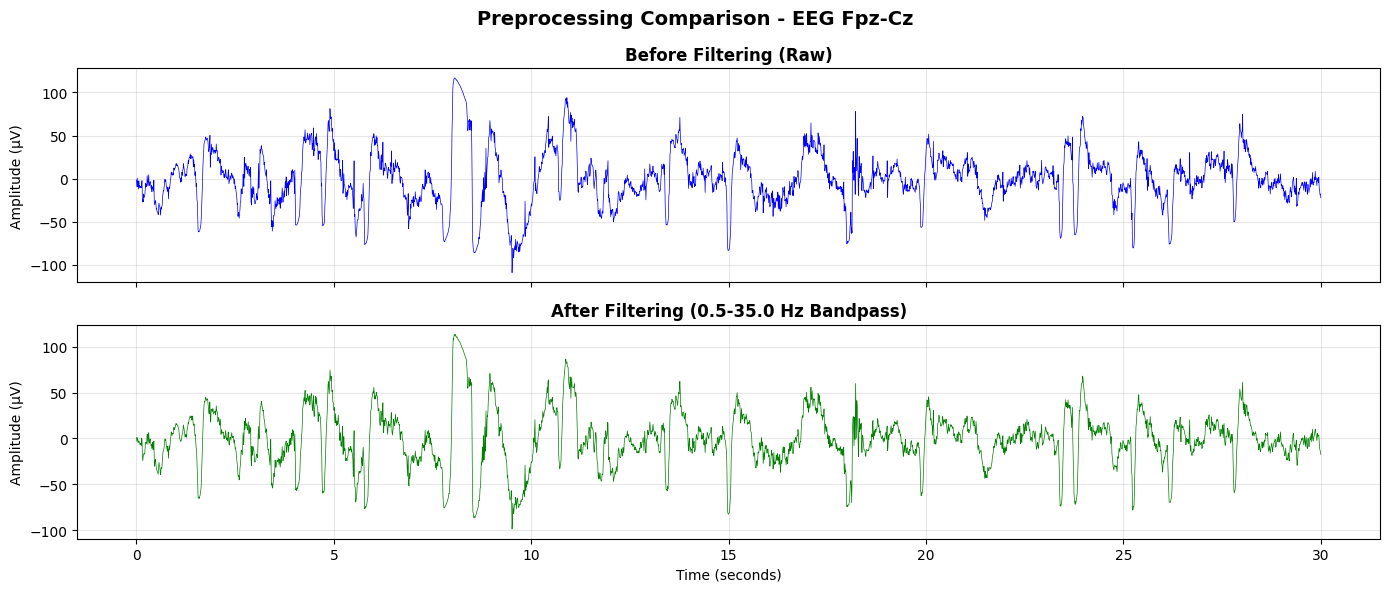

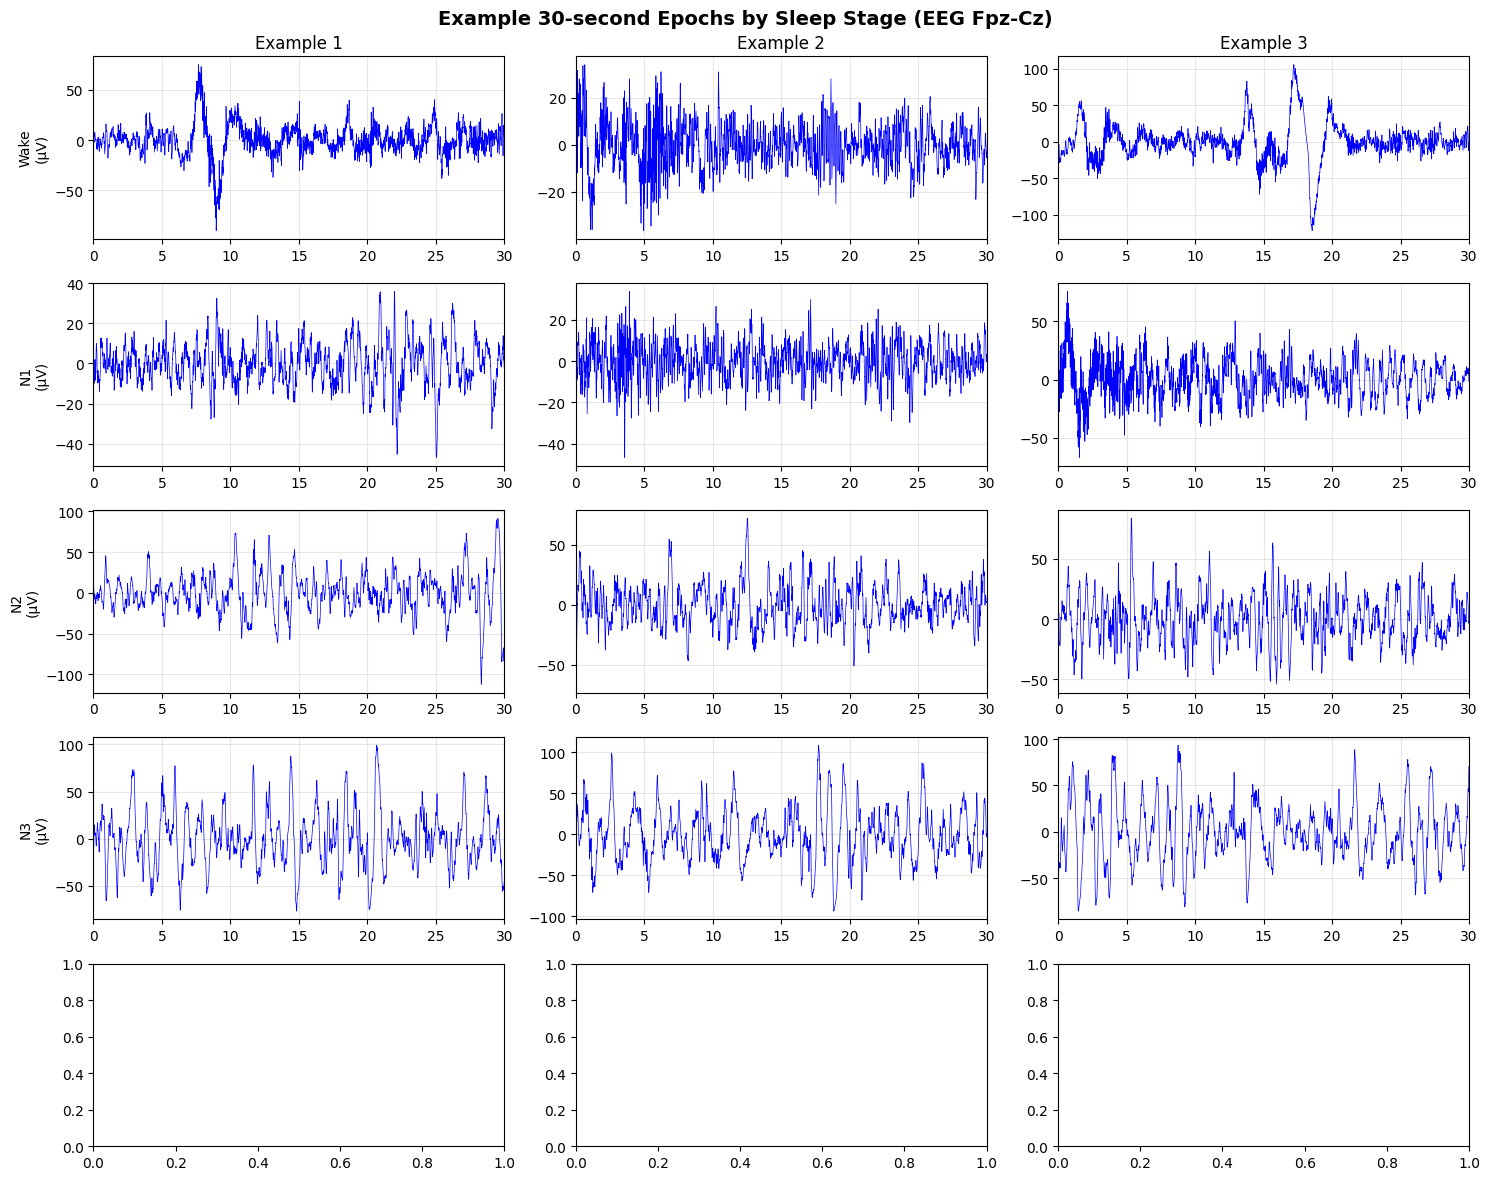

In [9]:
# VISUALIZE PREPROCESSED DATA
# Compare raw vs filtered signals, show epoch examples by sleep stage

def plot_preprocessing_comparison(raw_file, hypno_file, preprocessor, epoch_idx=100):
    """
    Show before/after preprocessing comparison.
    """
    # Load raw data
    raw_original, annotations = load_raw_eeg(raw_file, hypno_file)
    
    # Get filtered version
    raw_filtered = preprocessor.select_channels(raw_original)
    raw_filtered = preprocessor.apply_filters(raw_filtered)
    
    # Select same time segment
    epoch_start = epoch_idx * 30  # seconds
    duration = 30  # seconds
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    
    # Get channel data
    ch_name = 'EEG Fpz-Cz'
    ch_idx_orig = raw_original.ch_names.index(ch_name)
    ch_idx_filt = raw_filtered.ch_names.index(ch_name)
    
    sfreq = raw_original.info['sfreq']
    start_sample = int(epoch_start * sfreq)
    end_sample = int((epoch_start + duration) * sfreq)
    
    times = np.linspace(0, duration, end_sample - start_sample)
    
    # Plot original
    data_orig = raw_original.get_data()[ch_idx_orig, start_sample:end_sample] * 1e6
    axes[0].plot(times, data_orig, 'b-', linewidth=0.5)
    axes[0].set_ylabel('Amplitude (μV)')
    axes[0].set_title('Before Filtering (Raw)', fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Plot filtered
    data_filt = raw_filtered.get_data()[ch_idx_filt, start_sample:end_sample] * 1e6
    axes[1].plot(times, data_filt, 'g-', linewidth=0.5)
    axes[1].set_ylabel('Amplitude (μV)')
    axes[1].set_xlabel('Time (seconds)')
    axes[1].set_title(f'After Filtering ({Config.L_FREQ}-{Config.H_FREQ} Hz Bandpass)', 
                      fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(f'Preprocessing Comparison - {ch_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(Config.FIGURES_DIR / "preprocessing_comparison.png", dpi=150)
    plt.show()

def plot_epochs_by_stage(processed_data, n_examples=3):
    """
    Plot example epochs for each sleep stage.
    """
    epochs = processed_data['epochs_raw']  # Use raw for visualization
    labels = processed_data['labels']
    ch_names = processed_data['ch_names']
    sfreq = processed_data['sfreq']
    
    n_stages = len(Config.STAGE_NAMES)
    fig, axes = plt.subplots(n_stages, n_examples, figsize=(15, 12))
    
    times = np.arange(epochs.shape[2]) / sfreq
    
    for stage_idx, stage_name in enumerate(Config.STAGE_NAMES):
        # Find epochs with this stage
        stage_epochs_idx = np.where(labels == stage_idx)[0]
        
        if len(stage_epochs_idx) == 0:
            continue
        
        # Randomly select examples
        np.random.seed(Config.SEED)
        selected = np.random.choice(stage_epochs_idx, 
                                    size=min(n_examples, len(stage_epochs_idx)),
                                    replace=False)
        
        for i, epoch_idx in enumerate(selected):
            ax = axes[stage_idx, i]
            
            # Plot first EEG channel
            data = epochs[epoch_idx, 0, :] * 1e6  # Convert to μV
            ax.plot(times, data, 'b-', linewidth=0.5)
            
            if i == 0:
                ax.set_ylabel(f'{stage_name}\n(μV)')
            
            if stage_idx == 0:
                ax.set_title(f'Example {i+1}')
            
            if stage_idx == n_stages - 1:
                ax.set_xlabel('Time (s)')
            
            ax.set_xlim(0, 30)
            ax.grid(True, alpha=0.3)
    
    plt.suptitle('Example 30-second Epochs by Sleep Stage (EEG Fpz-Cz)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(Config.FIGURES_DIR / "epochs_by_stage.png", dpi=150)
    plt.show()

# Generate visualization figures
plot_preprocessing_comparison(psg_files[0], hypno_files[0], preprocessor)
plot_epochs_by_stage(processed_data)

CHANGEPOINT DETECTION EXAMPLES

Wake Stage (Epoch 54):


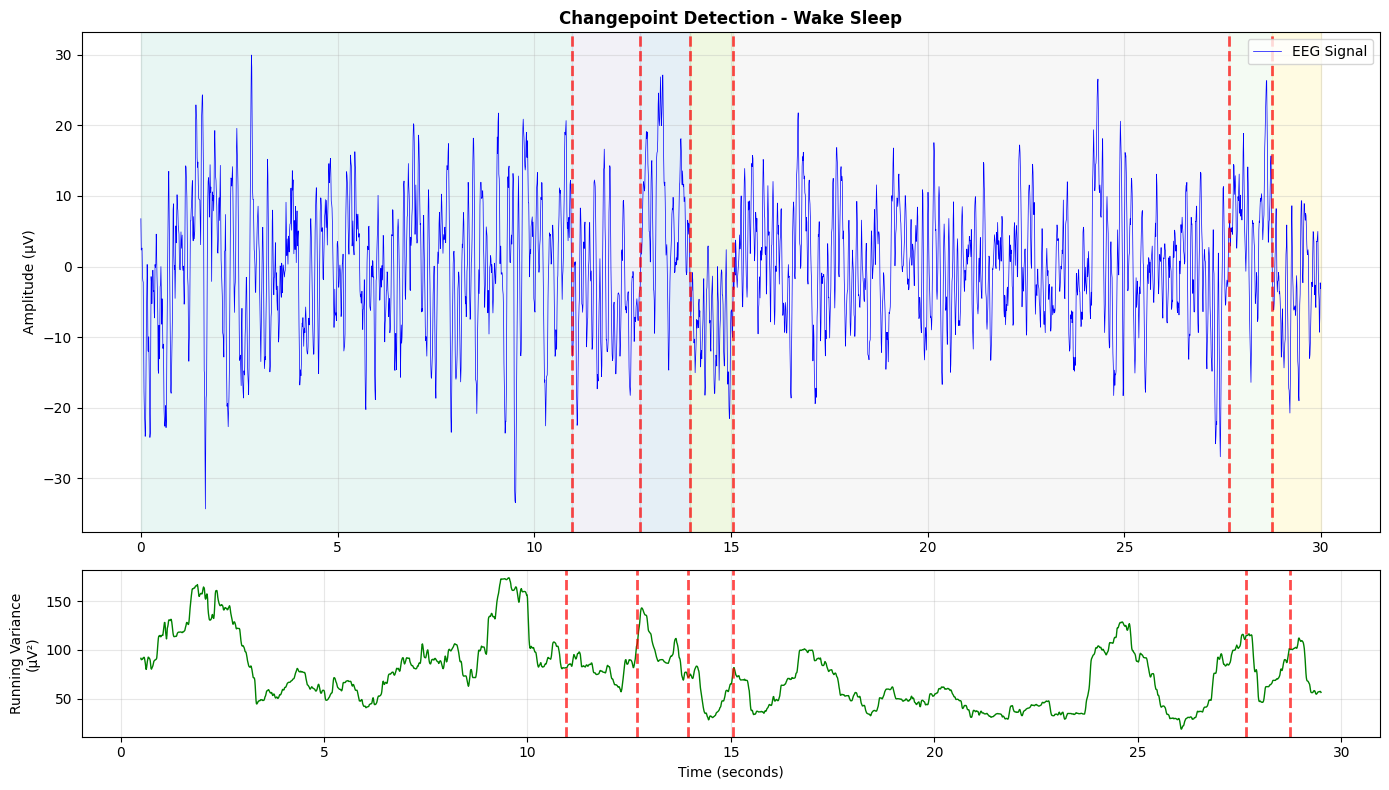


Detected 6 changepoints:
  Changepoint 1: t = 10.95s (sample 1095)
  Changepoint 2: t = 12.70s (sample 1270)
  Changepoint 3: t = 13.95s (sample 1395)
  Changepoint 4: t = 15.05s (sample 1505)
  Changepoint 5: t = 27.65s (sample 2765)
  Changepoint 6: t = 28.75s (sample 2875)

N1 Stage (Epoch 33):


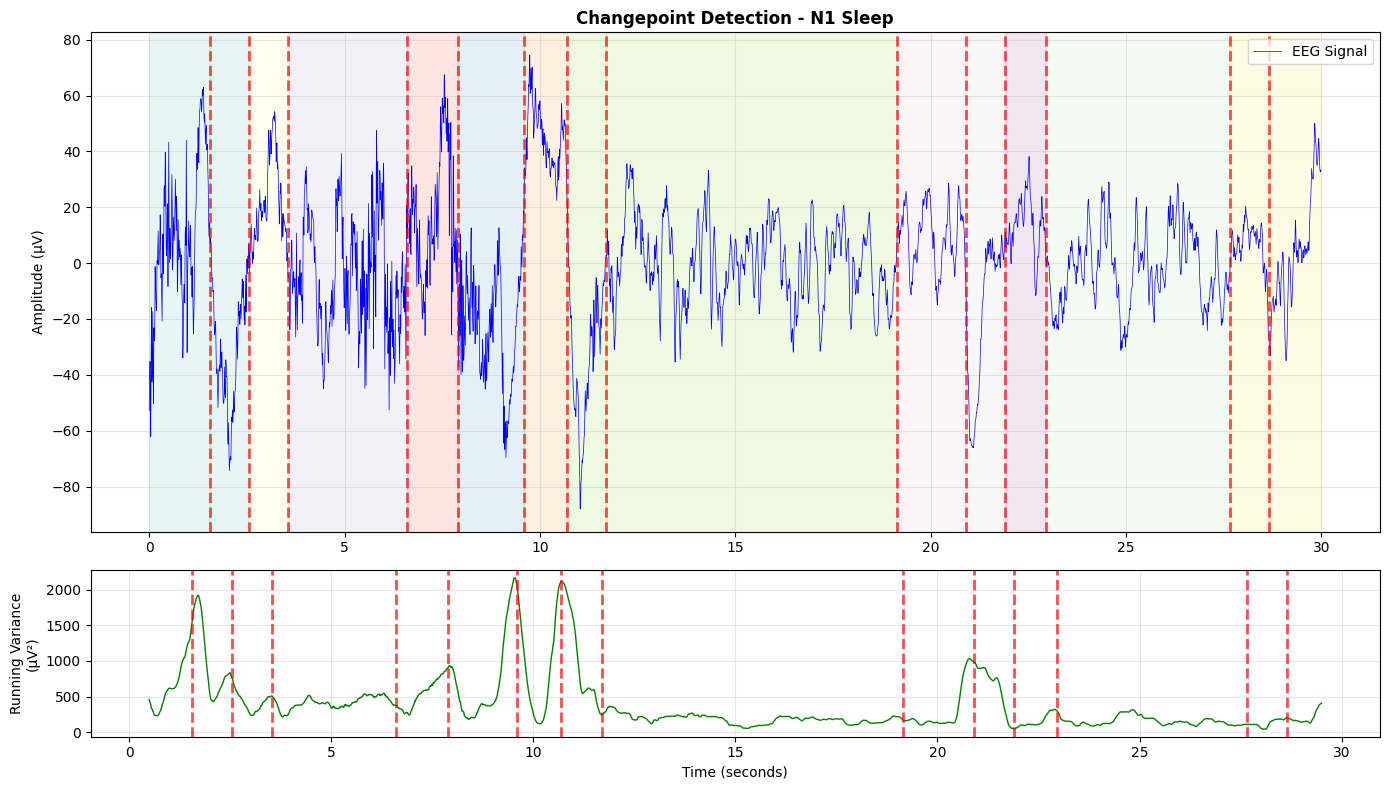


Detected 14 changepoints:
  Changepoint 1: t = 1.55s (sample 155)
  Changepoint 2: t = 2.55s (sample 255)
  Changepoint 3: t = 3.55s (sample 355)
  Changepoint 4: t = 6.60s (sample 660)
  Changepoint 5: t = 7.90s (sample 790)
  Changepoint 6: t = 9.60s (sample 960)
  Changepoint 7: t = 10.70s (sample 1070)
  Changepoint 8: t = 11.70s (sample 1170)
  Changepoint 9: t = 19.15s (sample 1915)
  Changepoint 10: t = 20.90s (sample 2090)
  Changepoint 11: t = 21.90s (sample 2190)
  Changepoint 12: t = 22.95s (sample 2295)
  Changepoint 13: t = 27.65s (sample 2765)
  Changepoint 14: t = 28.65s (sample 2865)

N2 Stage (Epoch 21):


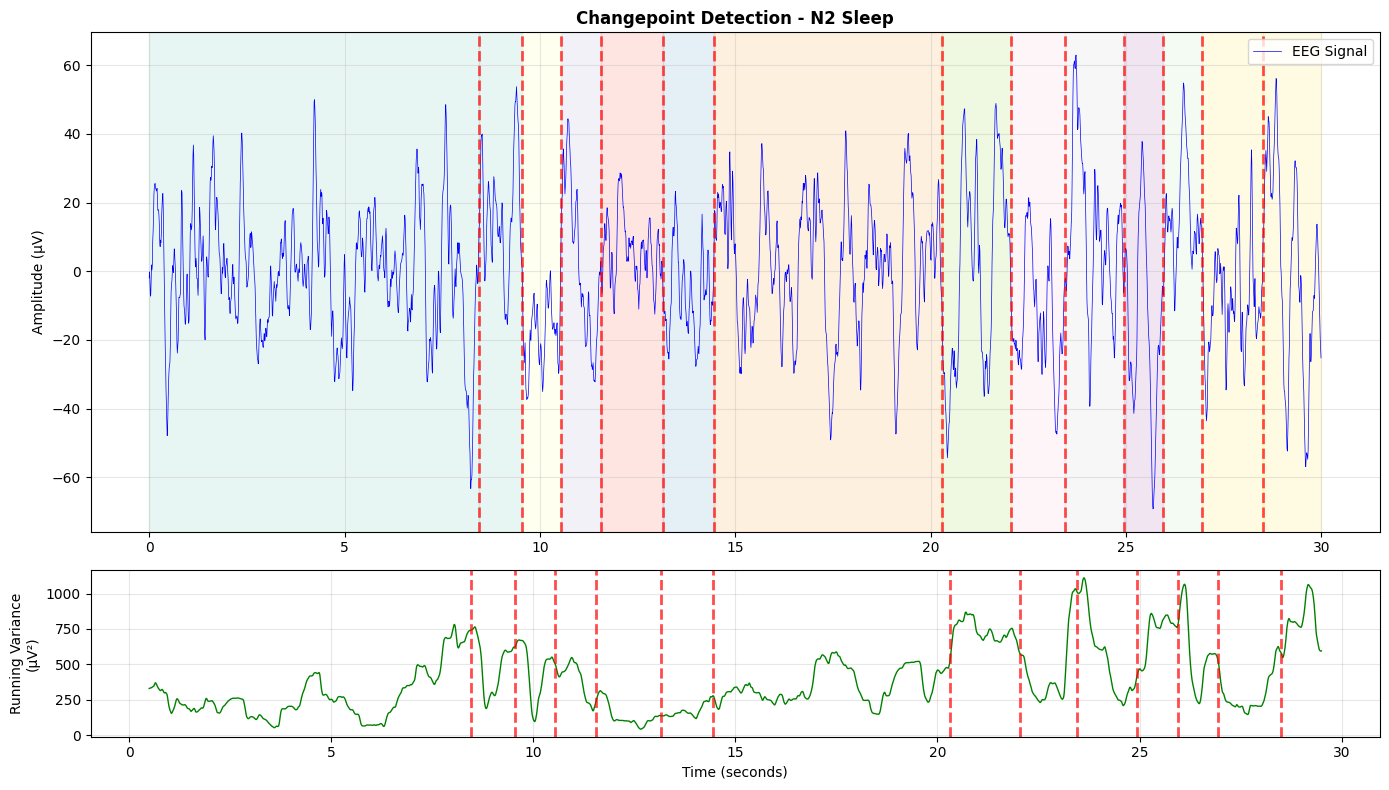


Detected 13 changepoints:
  Changepoint 1: t = 8.45s (sample 845)
  Changepoint 2: t = 9.55s (sample 955)
  Changepoint 3: t = 10.55s (sample 1055)
  Changepoint 4: t = 11.55s (sample 1155)
  Changepoint 5: t = 13.15s (sample 1315)
  Changepoint 6: t = 14.45s (sample 1445)
  Changepoint 7: t = 20.30s (sample 2030)
  Changepoint 8: t = 22.05s (sample 2205)
  Changepoint 9: t = 23.45s (sample 2345)
  Changepoint 10: t = 24.95s (sample 2495)
  Changepoint 11: t = 25.95s (sample 2595)
  Changepoint 12: t = 26.95s (sample 2695)
  Changepoint 13: t = 28.50s (sample 2850)

N3 Stage (Epoch 18):


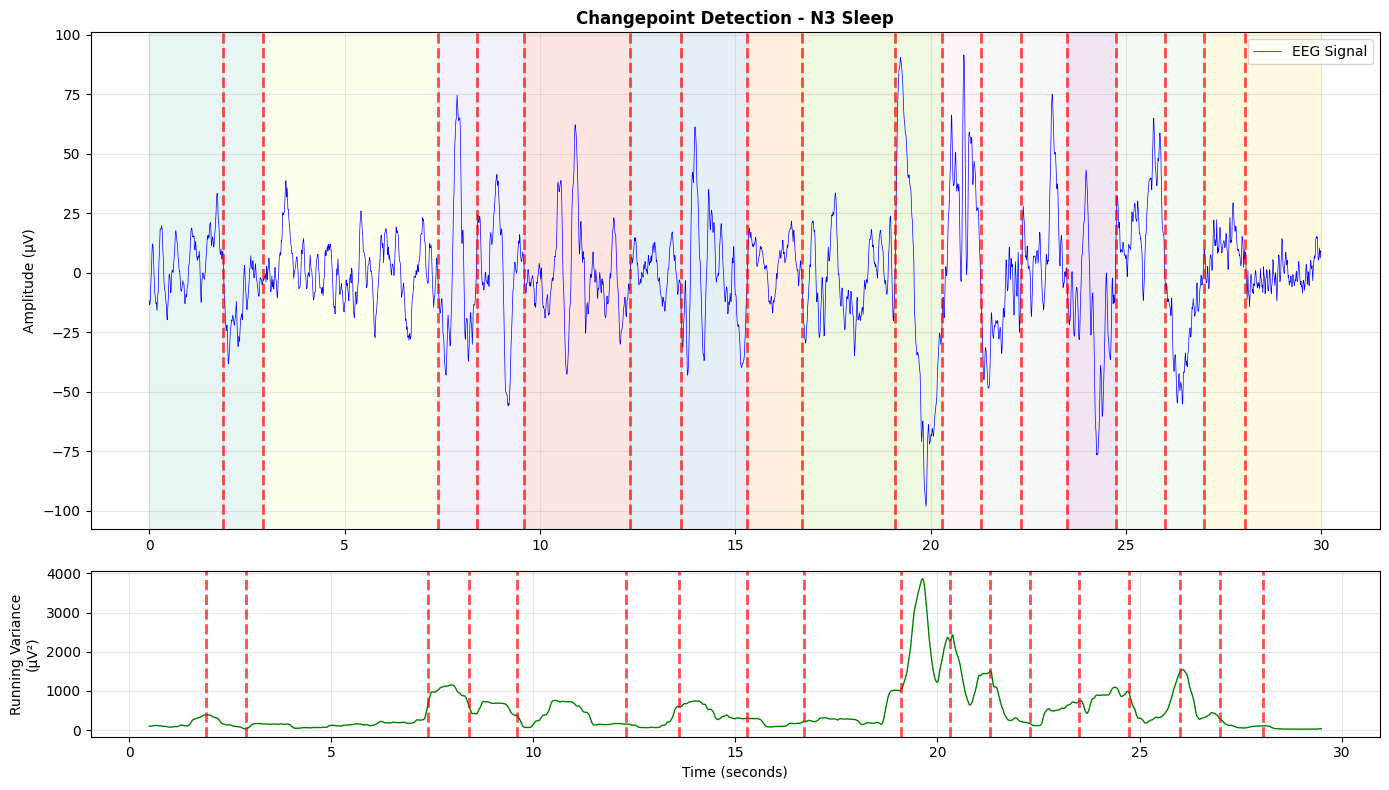


Detected 18 changepoints:
  Changepoint 1: t = 1.90s (sample 190)
  Changepoint 2: t = 2.90s (sample 290)
  Changepoint 3: t = 7.40s (sample 740)
  Changepoint 4: t = 8.40s (sample 840)
  Changepoint 5: t = 9.60s (sample 960)
  Changepoint 6: t = 12.30s (sample 1230)
  Changepoint 7: t = 13.60s (sample 1360)
  Changepoint 8: t = 15.30s (sample 1530)
  Changepoint 9: t = 16.70s (sample 1670)
  Changepoint 10: t = 19.10s (sample 1910)
  Changepoint 11: t = 20.30s (sample 2030)
  Changepoint 12: t = 21.30s (sample 2130)
  Changepoint 13: t = 22.30s (sample 2230)
  Changepoint 14: t = 23.50s (sample 2350)
  Changepoint 15: t = 24.75s (sample 2475)
  Changepoint 16: t = 26.00s (sample 2600)
  Changepoint 17: t = 27.00s (sample 2700)
  Changepoint 18: t = 28.05s (sample 2805)


In [10]:
# CHANGEPOINT DETECTION WITH PELT
# Implement and visualize changepoint detection on EEG epochs

class ChangepointDetector:
    """
    Changepoint detection for EEG signals using PELT algorithm.
    
    This detects abrupt changes in signal properties that may correspond
    to brain state transitions (e.g., sleep stage changes).
    """
    
    def __init__(self, model="rbf", min_size=100, penalty=10):
        """
        Initialize changepoint detector.
        
        Parameters:
        -----------
        model : str
            Cost function model. Options:
            - "rbf": Radial basis function (good for general changes)
            - "l2": Squared error (good for mean shifts)
            - "l1": Absolute error (robust to outliers)
        min_size : int
            Minimum samples between changepoints
        penalty : float
            Penalty for adding changepoints (higher = fewer changepoints)
        """
        self.model = model
        self.min_size = min_size
        self.penalty = penalty
    
    def detect(self, signal):
        """
        Detect changepoints in a 1D signal.
        
        Parameters:
        -----------
        signal : np.ndarray
            1D signal array
            
        Returns:
        --------
        list : Indices of detected changepoints
        """
        # Initialize PELT algorithm
        algo = rpt.Pelt(model=self.model, min_size=self.min_size, jump=5)
        
        # Fit and predict
        algo.fit(signal)
        changepoints = algo.predict(pen=self.penalty)
        
        # Remove the last element (always equals signal length)
        if len(changepoints) > 0 and changepoints[-1] == len(signal):
            changepoints = changepoints[:-1]
        
        return changepoints
    
    def detect_multichannel(self, data):
        """
        Detect changepoints in multichannel data.
        
        Parameters:
        -----------
        data : np.ndarray
            2D array of shape (n_channels, n_samples)
            
        Returns:
        --------
        list : Changepoints detected across all channels
        dict : Per-channel changepoints
        """
        all_changepoints = []
        channel_changepoints = {}
        
        for ch_idx in range(data.shape[0]):
            cps = self.detect(data[ch_idx])
            channel_changepoints[ch_idx] = cps
            all_changepoints.extend(cps)
        
        # Find consensus changepoints (appearing in multiple channels)
        # For now, return union of all changepoints
        unique_cps = sorted(list(set(all_changepoints)))
        
        return unique_cps, channel_changepoints
    
    def compute_segment_statistics(self, signal, changepoints):
        """
        Compute statistics for each segment defined by changepoints.
        
        Parameters:
        -----------
        signal : np.ndarray
            1D signal
        changepoints : list
            List of changepoint indices
            
        Returns:
        --------
        list : List of dicts containing segment statistics
        """
        # Add start and end points
        boundaries = [0] + list(changepoints) + [len(signal)]
        
        segments = []
        for i in range(len(boundaries) - 1):
            start = boundaries[i]
            end = boundaries[i + 1]
            segment_data = signal[start:end]
            
            segments.append({
                'start': start,
                'end': end,
                'duration': end - start,
                'mean': np.mean(segment_data),
                'std': np.std(segment_data),
                'min': np.min(segment_data),
                'max': np.max(segment_data),
                'energy': np.sum(segment_data ** 2)
            })
        
        return segments

def plot_changepoint_detection(epoch_data, sfreq, detector, channel_idx=0, 
                               title="Changepoint Detection", save_path=None):
    """
    Visualize changepoint detection on a single epoch.
    
    Parameters:
    -----------
    epoch_data : np.ndarray
        Epoch data of shape (n_channels, n_samples)
    sfreq : float
        Sampling frequency
    detector : ChangepointDetector
        Changepoint detector instance
    channel_idx : int
        Which channel to plot
    """
    signal = epoch_data[channel_idx]
    times = np.arange(len(signal)) / sfreq
    
    # Detect changepoints
    changepoints = detector.detect(signal)
    
    # Create figure
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), 
                             gridspec_kw={'height_ratios': [3, 1]})
    
    # Plot signal with changepoints
    ax1 = axes[0]
    ax1.plot(times, signal * 1e6, 'b-', linewidth=0.5, label='EEG Signal')
    
    # Mark changepoints
    for cp in changepoints:
        cp_time = cp / sfreq
        ax1.axvline(x=cp_time, color='red', linestyle='--', linewidth=2, alpha=0.7)
    
    ax1.set_ylabel('Amplitude (μV)')
    ax1.set_title(title, fontsize=12, fontweight='bold')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # Add segment coloring
    colors = plt.cm.Set3(np.linspace(0, 1, len(changepoints) + 1))
    boundaries = [0] + changepoints + [len(signal)]
    for i in range(len(boundaries) - 1):
        start_t = boundaries[i] / sfreq
        end_t = boundaries[i + 1] / sfreq
        ax1.axvspan(start_t, end_t, alpha=0.2, color=colors[i])
    
    # Plot running variance (shows where signal properties change)
    ax2 = axes[1]
    window = int(sfreq * 1)  # 1-second window
    running_var = pd.Series(signal).rolling(window=window, center=True).var()
    ax2.plot(times, running_var * 1e12, 'g-', linewidth=1)
    ax2.set_ylabel('Running Variance\n(μV²)')
    ax2.set_xlabel('Time (seconds)')
    ax2.grid(True, alpha=0.3)
    
    # Mark changepoints on variance plot too
    for cp in changepoints:
        cp_time = cp / sfreq
        ax2.axvline(x=cp_time, color='red', linestyle='--', linewidth=2, alpha=0.7)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()
    
    print(f"\nDetected {len(changepoints)} changepoints:")
    for i, cp in enumerate(changepoints):
        print(f"  Changepoint {i+1}: t = {cp/sfreq:.2f}s (sample {cp})")
    
    return changepoints

# Create changepoint detector
cp_detector = ChangepointDetector(
    model=Config.CP_MODEL,
    min_size=Config.CP_MIN_SIZE,
    penalty=Config.CP_PENALTY
)

# Test on different sleep stages
print("=" * 60)
print("CHANGEPOINT DETECTION EXAMPLES")
print("=" * 60)

epochs = processed_data['epochs_raw']
labels = processed_data['labels']
sfreq = processed_data['sfreq']

# Show changepoint detection for each sleep stage
for stage_idx, stage_name in enumerate(Config.STAGE_NAMES):
    stage_epochs = np.where(labels == stage_idx)[0]
    if len(stage_epochs) == 0:
        continue
    
    # Pick a random epoch
    np.random.seed(Config.SEED + stage_idx)
    epoch_idx = np.random.choice(stage_epochs)
    
    print(f"\n{stage_name} Stage (Epoch {epoch_idx}):")
    plot_changepoint_detection(
        epochs[epoch_idx], 
        sfreq, 
        cp_detector,
        title=f"Changepoint Detection - {stage_name} Sleep",
        save_path=Config.FIGURES_DIR / f"changepoints_{stage_name.lower()}.png"
    )

In [11]:
# Process all downloaded subjects and combine into single dataset

def batch_process_all_subjects(psg_files, hypno_files, preprocessor, verbose=True):
    """
    Process all subjects and combine into unified dataset.
    
    Returns:
    --------
    dict : Combined processed data with subject tracking
    """
    all_epochs = []
    all_epochs_raw = []
    all_labels = []
    all_times = []
    all_subject_ids = []
    all_bad_masks = []
    
    n_files = len(psg_files)
    
    for i, (psg_file, hypno_file) in enumerate(zip(psg_files, hypno_files)):
        if verbose:
            print(f"\n[{i+1}/{n_files}] ", end="")
        
        try:
            result = preprocessor.process_recording(psg_file, hypno_file, verbose=verbose)
            
            if result is None:
                continue
            
            # Extract subject ID from filename (e.g., "SC4001E0" from path)
            subject_id = Path(psg_file).stem.split('-')[0]  # Gets "SC4001E0"
            
            n_epochs = len(result['epochs'])
            
            all_epochs.append(result['epochs'])
            all_epochs_raw.append(result['epochs_raw'])
            all_labels.append(result['labels'])
            all_times.append(result['times'])
            all_subject_ids.extend([subject_id] * n_epochs)
            all_bad_masks.append(result['bad_epochs_mask'])
            
        except Exception as e:
            print(f"  Error processing {Path(psg_file).name}: {e}")
            continue
    
    if len(all_epochs) == 0:
        raise ValueError("No subjects were successfully processed!")
    
    # Combine all data
    combined = {
        'epochs': np.concatenate(all_epochs, axis=0),
        'epochs_raw': np.concatenate(all_epochs_raw, axis=0),
        'labels': np.concatenate(all_labels, axis=0),
        'times': np.concatenate(all_times, axis=0),
        'subject_ids': np.array(all_subject_ids),
        'bad_epochs_mask': np.concatenate(all_bad_masks, axis=0),
        'sfreq': preprocessor.config.SFREQ_TARGET,
        'ch_names': preprocessor.config.EEG_CHANNELS,
        'n_subjects': len(set(all_subject_ids))
    }
    
    if verbose:
        print("\n" + "=" * 60)
        print("BATCH PROCESSING COMPLETE")
        print("=" * 60)
        print(f"  Total subjects: {combined['n_subjects']}")
        print(f"  Total epochs: {len(combined['epochs'])}")
        print(f"  Epochs shape: {combined['epochs'].shape}")
        print(f"  Bad epochs: {np.sum(combined['bad_epochs_mask'])} "
              f"({100*np.mean(combined['bad_epochs_mask']):.1f}%)")
        
        print("\n  Stage distribution:")
        for stage_idx, stage_name in enumerate(Config.STAGE_NAMES):
            count = np.sum(combined['labels'] == stage_idx)
            pct = 100 * count / len(combined['labels'])
            print(f"    {stage_name}: {count:,} ({pct:.1f}%)")
    
    return combined

# Run batch processing
print("=" * 60)
print("BATCH PROCESSING ALL SUBJECTS")
print("=" * 60)

all_data = batch_process_all_subjects(psg_files, hypno_files, preprocessor)

      N1: 37 (63.8%)
      N2: 6 (10.3%)
      N3: 7 (12.1%)
      REM: 0 (0.0%)

[113/147] 
Processing: SC4582G0-PSG.edf
  Step 1/6: Loading raw data...
  Step 2/6: Selecting channels...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
  Step 3/6: Applying filters...
  Applying bandpass filter: 0.5-35.0 Hz
  Step 4/6: Extracting epochs...
    Extracted 56 epochs
  Step 5/6: Detecting artifacts...
    Found 8 bad epochs (14.3%)
  Step 6/6: Normalizing...
  Done!

  Summary:
    Total epochs: 56
    Good epochs:  48
    Bad epochs:   8
    Channels:     ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EOG horizontal']
    Sampling freq: 100.0 Hz

    Stage distribution:
      Wake: 10 (17.9%)
      N1: 30 (53.6%)
      N2: 10 (17.9%)
      N3: 4 (7.1%)
      REM: 2 (3.6%)

[114/147] 
Processing: SC4591G0-PSG.edf
  Step 1/6: Loading raw data...
  Step 2/6: Selecting channels...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
  Step 3/6: Applying

In [12]:
# FIXED CHANGEPOINT BASELINE (FOR EVALUATION ONLY)
class FixedChangepointBaseline:
    """
    Fixed PELT changepoint detection for baseline comparison.
    
    In the revised NeuroState approach, this is used ONLY for:
    - Generating alignment targets for Dice coefficient evaluation
    - Comparing against the learned differentiable changepoints
    
    NOT used during model training - changepoints are learned end-to-end.
    """
    
    def __init__(self, model="rbf", min_size=100, penalty=10):
        self.model = model
        self.min_size = min_size
        self.penalty = penalty
    
    def detect(self, signal):
        """Detect changepoints using PELT (baseline method)."""
        algo = rpt.Pelt(model=self.model, min_size=self.min_size, jump=5)
        algo.fit(signal)
        changepoints = algo.predict(pen=self.penalty)
        if len(changepoints) > 0 and changepoints[-1] == len(signal):
            changepoints = changepoints[:-1]
        return changepoints
    
    def generate_boundary_targets(self, epochs, sfreq, verbose=True):
        """
        Generate soft boundary targets for evaluation.
        
        Returns b(t) ∈ [0,1] at each position, where 1 = changepoint.
        Used to compute Dice coefficient with learned boundaries.
        """
        n_epochs, n_channels, n_samples = epochs.shape
        boundary_targets = np.zeros((n_epochs, n_samples), dtype=np.float32)
        
        iterator = tqdm(range(n_epochs), desc="Generating PELT boundaries") if verbose else range(n_epochs)
        
        for i in iterator:
            # Detect on first channel (use raw/unnormalized data)
            cps = self.detect(epochs[i, 0, :])
            # Create soft targets (Gaussian around changepoints)
            for cp in cps:
                sigma = sfreq * 0.5  # 0.5 second gaussian width
                positions = np.arange(n_samples)
                gaussian = np.exp(-0.5 * ((positions - cp) / sigma) ** 2)
                boundary_targets[i] = np.maximum(boundary_targets[i], gaussian)
        
        return boundary_targets

In [13]:
# COMPUTE MULTI-SCALE GROUND TRUTH (OPTIONAL - FOR EVALUATION)
def compute_multiscale_ground_truth(epochs, labels, sfreq, verbose=True):
    """
    Compute ground truth changepoints at multiple scales for evaluation.
    
    Aligned with NeuroState's 3 scales: 0.5s, 2s, 10s
    
    Scale 1 (0.5s): Within-epoch micro-transitions (from PELT, fine)
    Scale 2 (2s): Sleep spindles, K-complexes (from PELT, coarse)  
    Scale 3 (10s): Coarse structure / sleep stage transitions
    
    Returns:
    --------
    dict : Multi-scale boundary annotations
    """
    n_epochs = len(epochs)
    n_samples = epochs.shape[2]
    
    ground_truth = {
        'scale_fine': np.zeros((n_epochs, n_samples), dtype=np.float32),   # 0.5s
        'scale_medium': np.zeros((n_epochs, n_samples), dtype=np.float32), # 2s
        'scale_coarse': np.zeros((n_epochs, n_samples), dtype=np.float32), # 10s
        'stage_transitions': []
    }
    
    # Scale 1 & 2: PELT with different parameters
    min_size_fine = max(int(0.5 * sfreq), 10)    # 0.5s or 10 samples min
    min_size_medium = max(int(2 * sfreq), 50)    # 2s or 50 samples min
    
    iterator = tqdm(range(n_epochs), desc="Computing multi-scale GT") if verbose else range(n_epochs)
    
    for i in iterator:
        signal = epochs[i, 0, :]  # First channel
        
        # Fine scale (0.5s)
        try:
            algo_fine = rpt.Pelt(model="rbf", min_size=min_size_fine, jump=5)
            algo_fine.fit(signal)
            cps_fine = algo_fine.predict(pen=5)
            for cp in cps_fine[:-1]:  # Exclude last (= signal length)
                if 0 < cp < n_samples:
                    # Gaussian soft target
                    sigma = sfreq * 0.25
                    gaussian = np.exp(-0.5 * ((np.arange(n_samples) - cp) / sigma) ** 2)
                    ground_truth['scale_fine'][i] = np.maximum(
                        ground_truth['scale_fine'][i], gaussian
                    )
        except Exception:
            pass
        
        # Medium scale (2s)
        try:
            algo_medium = rpt.Pelt(model="rbf", min_size=min_size_medium, jump=10)
            algo_medium.fit(signal)
            cps_medium = algo_medium.predict(pen=15)
            for cp in cps_medium[:-1]:
                if 0 < cp < n_samples:
                    sigma = sfreq * 1.0
                    gaussian = np.exp(-0.5 * ((np.arange(n_samples) - cp) / sigma) ** 2)
                    ground_truth['scale_medium'][i] = np.maximum(
                        ground_truth['scale_medium'][i], gaussian
                    )
        except Exception:
            pass
    
    # Scale 3: Sleep stage transitions (between epochs)
    for i in range(1, n_epochs):
        if labels[i] != labels[i-1]:
            ground_truth['stage_transitions'].append({
                'epoch_idx': i,
                'from_stage': Config.STAGE_NAMES[labels[i-1]],
                'to_stage': Config.STAGE_NAMES[labels[i]]
            })
    
    if verbose:
        print(f"\n  Found {len(ground_truth['stage_transitions'])} stage transitions")
    
    return ground_truth

In [14]:
# SAVE PROCESSED DATA FOR NEUROSTATE
def save_for_neurostate(data, output_path, include_pelt_baseline=True, 
                        include_multiscale_gt=False, verbose=True):
    """
    Save preprocessed data in format for NeuroState training.
    
    The model learns changepoints end-to-end, so we save:
    - Epochs (normalized input)
    - Labels (for downstream tasks)
    - Subject IDs (for proper train/val/test splits)
    - Optional: PELT baseline for evaluation comparison
    - Optional: Multi-scale ground truth for evaluation
    
    Parameters:
    -----------
    data : dict
        Output from batch_process_all_subjects()
    output_path : str or Path
        Where to save the HDF5 file
    include_pelt_baseline : bool
        Whether to compute and save PELT boundaries
    include_multiscale_gt : bool
        Whether to compute and save multi-scale ground truth
    """
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    if verbose:
        print(f"\nSaving to {output_path}...")
    
    with h5py.File(output_path, 'w') as f:
        # ===================
        # Core training data
        # ===================
        f.create_dataset('epochs', 
                        data=data['epochs'].astype(np.float32), 
                        compression='gzip',
                        chunks=(min(100, len(data['epochs'])), 
                               data['epochs'].shape[1], 
                               data['epochs'].shape[2]))
        
        f.create_dataset('labels', 
                        data=data['labels'].astype(np.int32),
                        compression='gzip')
        
        f.create_dataset('times', 
                        data=data['times'].astype(np.float32))
        
        # Subject IDs for proper splits (avoid data leakage)
        subject_ids_encoded = np.array(data['subject_ids'], dtype='S20')
        f.create_dataset('subject_ids', data=subject_ids_encoded)
        
        # Bad epochs mask (for optional filtering)
        f.create_dataset('bad_epochs_mask', 
                        data=data['bad_epochs_mask'].astype(bool))
        
        # ===================
        # Metadata
        # ===================
        f.attrs['dataset'] = 'sleep-edf'
        f.attrs['sfreq'] = data['sfreq']
        f.attrs['n_channels'] = data['epochs'].shape[1]
        f.attrs['n_samples'] = data['epochs'].shape[2]
        f.attrs['epoch_duration'] = Config.EPOCH_DURATION
        f.attrs['n_classes'] = len(Config.STAGE_NAMES)
        f.attrs['class_names'] = str(Config.STAGE_NAMES)
        f.attrs['ch_names'] = str(data['ch_names'])
        f.attrs['n_subjects'] = data['n_subjects']
        f.attrs['n_epochs'] = len(data['epochs'])
        
        # ===================
        # Optional: PELT baseline for evaluation
        # ===================
        if include_pelt_baseline:
            if verbose:
                print("  Computing PELT baseline boundaries...")
            
            baseline = FixedChangepointBaseline(
                model=Config.CP_MODEL,
                min_size=Config.CP_MIN_SIZE,
                penalty=Config.CP_PENALTY
            )
            # Use raw (unnormalized) epochs for PELT
            boundary_targets = baseline.generate_boundary_targets(
                data['epochs_raw'], 
                data['sfreq'],
                verbose=verbose
            )
            f.create_dataset('pelt_boundaries', 
                            data=boundary_targets,
                            compression='gzip')
            f.attrs['has_pelt_baseline'] = True
        else:
            f.attrs['has_pelt_baseline'] = False
        
        # ===================
        # Optional: Multi-scale ground truth
        # ===================
        if include_multiscale_gt:
            if verbose:
                print("  Computing multi-scale ground truth...")
            
            multiscale_gt = compute_multiscale_ground_truth(
                data['epochs_raw'],
                data['labels'],
                data['sfreq'],
                verbose=verbose
            )
            
            f.create_dataset('gt_scale_fine', 
                            data=multiscale_gt['scale_fine'],
                            compression='gzip')
            f.create_dataset('gt_scale_medium', 
                            data=multiscale_gt['scale_medium'],
                            compression='gzip')
            f.create_dataset('gt_scale_coarse', 
                            data=multiscale_gt['scale_coarse'],
                            compression='gzip')
            
            # Save stage transitions as structured array
            n_transitions = len(multiscale_gt['stage_transitions'])
            if n_transitions > 0:
                transition_epochs = np.array([t['epoch_idx'] for t in multiscale_gt['stage_transitions']])
                f.create_dataset('stage_transition_epochs', data=transition_epochs)
            
            f.attrs['has_multiscale_gt'] = True
            f.attrs['n_stage_transitions'] = n_transitions
        else:
            f.attrs['has_multiscale_gt'] = False
    
    # Print summary
    if verbose:
        file_size_mb = output_path.stat().st_size / (1024 * 1024)
        print(f"\n✓ Saved successfully!")
        print(f"  File: {output_path}")
        print(f"  Size: {file_size_mb:.1f} MB")
        print(f"  Epochs: {data['epochs'].shape}")
        print(f"  Subjects: {data['n_subjects']}")
        print(f"  PELT baseline: {include_pelt_baseline}")
        print(f"  Multi-scale GT: {include_multiscale_gt}")

In [15]:
# EXECUTE SAVE
# Save the processed data
output_file = Config.PROCESSED_DIR / "sleep_edf_processed.h5"

save_for_neurostate(
    all_data,
    output_file,
    include_pelt_baseline=True,      # For Dice coefficient evaluation
    include_multiscale_gt=True,      # For multi-scale evaluation
    verbose=True
)


Saving to data/processed/sleep_edf_processed.h5...
  Computing PELT baseline boundaries...
Generating PELT boundaries:  32%|███▏      | 2357/7360 [2:40:13<5:40:06,  4.08s/it]


KeyboardInterrupt: 

In [ ]:
# VERIFY SAVED DATA
def verify_saved_data(h5_path):
    """Load and verify the saved HDF5 file."""
    print(f"\nVerifying {h5_path}...")
    
    with h5py.File(h5_path, 'r') as f:
        print("\n  Datasets:")
        for key in f.keys():
            shape = f[key].shape
            dtype = f[key].dtype
            print(f"    {key}: {shape} ({dtype})")
        
        print("\n  Attributes:")
        for key, value in f.attrs.items():
            print(f"    {key}: {value}")
        
        # Quick data check
        epochs = f['epochs'][:]
        labels = f['labels'][:]
        
        print(f"\n  Data validation:")
        print(f"    Epochs range: [{epochs.min():.3f}, {epochs.max():.3f}]")
        print(f"    Labels unique: {np.unique(labels)}")
        print(f"    Any NaN: {np.any(np.isnan(epochs))}")
        print(f"    Any Inf: {np.any(np.isinf(epochs))}")

verify_saved_data(output_file)

print("\n" + "=" * 60)
print("SLEEP-EDF PREPROCESSING COMPLETE!")
print("=" * 60)
print(f"\nOutput file: {output_file.absolute()}")

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=30d601c2-0a51-44b0-ac6c-72cf48d1679e' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>